# Lab 4. Data analysis workshop

Igor Gitelman  v0.3

In this lab we will use a Jupyter notebook as an experimental logbook. That means the notebook will contain not only code, but also short text explanations. You can answer the text parts in a markdown (text) cell — it does not have to be code.

In this lab you will:

  1. **Using the notebook as a logbook tool:** Learn how to structure your notebook so that it serves as a real experimental record — combining code, results, plots, and short explanations in one document.
  
  2. **Weighted average and uncertainty handling**: Learn how to combine repeated measurements with different errors using the weighted average formula

  3. **Work with uncertainties**: fit the same data with several models and use the measurement errors as weights. Then we will evaluate the fits using reduced chi-squared $\chi^2_\nu$. This shows how error bars affect the result, not just the plot.

So: first write, then code, then interpret — all in one notebook.

In [354]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

<h1>Average the data</h1>

Let's prepare a measured data set of length $N=10$.

This means we measure the desired quantity ten times using the same method.

In [355]:
mu = 1
sigma = 2

N = 10  # number of measurements

X = mu + sigma * np.random.randn(N)
print(f"The first ten measurements: {X[:10]}")

The first ten measurements: [-0.58096188  0.22231471  1.11486674  3.07124778 -1.68916675  0.26562979
 -2.99257389  0.57836797  2.78869457 -0.23123755]


Now let's calculate their average and standard deviation.

<p> Using the known formulas: </p>

$$\langle X \rangle = \frac{\sum X_i}{N},\,\,\, STD(X) = \sqrt{\frac{1}{N-1} \left(\sum (X_i-\langle X \rangle)^2 \right)} $$
<p> Here, \( N \) is the number of measurements (the length of the measurement array). Pay attention to Bessel’s correction. </p>

In [356]:
# TODO: replace np.nan with your calculation use numpy mean and std(x,ddof=1)
mu = 1
sigma = 2

N = 1000  # number of measurements

X = mu + sigma * np.random.randn(N)
mu_X = np.mean(X)
std_X = np.std(X, ddof=1)

print(f"The measured value: {mu_X:.3f}")
print(f"The standard deviation: {std_X:.3f}")

The measured value: 1.033
The standard deviation: 2.011


* Try varying N, the number of measurements.
* Do the measured value and standard deviation change?
* Why?

The uncertainty of the average is

$s=\frac{STD(X)}{\sqrt{N}}$
 * Compute in Python
 * Write as ‘value ± uncertainty’.
 * Write the physical relative uncertainty (error) $\frac{\text{uncertainty}}{\text{value}}$
 * Does the number of measurements affect the relative uncertainty of the average?

In [357]:
unc_mean = std_X / np.sqrt(N)
rel_unc = unc_mean / mu_X

print(f"Measured value: {mu_X:.3f} ± {unc_mean:.3f}")
print(f"Relative uncertainty: {rel_unc:.3f}")

Measured value: 1.033 ± 0.064
Relative uncertainty: 0.062


# Weighted average

When measurements have different uncertainties, they do not contribute equally to the estimate of the true value.
A result with a smaller uncertainty is statistically more reliable and should therefore influence the average value more strongly than a less precise one.

The weighted average incorporates this by assigning each measurement a weight proportional to the inverse of its variance, $w_i = \frac{1}{\sigma_i^2}$.
This means that precise measurements (small $\sigma_i$) have larger weights, while uncertain ones contribute less.

Mathematically, the best estimate of the average is

$$\langle X \rangle_w=\frac{\sum_i w_i X_i}{\sum_i w_i}, \,\,\, \sigma _{\langle X \rangle_w} =\frac{1}{\sqrt{\sum_i w_i}}$$

And the final result would be

$$ X=\langle X \rangle_w \pm \sigma _{\langle X \rangle_w}$$

This approach ensures that all measurements are combined consistently, reflecting both their values and their statistical confidence.

## Step 1 — Start with simple average

<p> You measured the same physical quantity three times:</p>



```
x=[1.05,0.97,1.10]
```

* Compute the simple (unweighted) average using `np.mean()`.


In [358]:
x = np.array([1.05, 0.97, 1.10])
# TODO: compute the simple average
mu_simple = np.mean(x)

In [359]:
x = np.array([1.05, 0.97, 1.10])
# TODO: compute the simple average
mu_simple = np.mean(x)

## Step 2 — Notice the problem
<p>Now suppose you also know the uncertainties of each measurement: </p>

`sigma = np.array([0.10, 0.30, 0.20])`

* Task: print the values and their uncertainties in one line each. ($A\pm \delta a$)
* Question: are these three measurements equally reliable? Compare their relative uncertainties, $\delta a/A$

In [360]:
sigma = np.array((0.1, 0.3, 0.2))
for meas, unc in zip(x, sigma):
    print(f"{meas:.3f} ± {unc:.3f} *** {unc / meas:.3f}")

1.050 ± 0.100 *** 0.095
0.970 ± 0.300 *** 0.309
1.100 ± 0.200 *** 0.182


## Step 3 — Ask: Should all of them count equally?

If one measurement has uncertainty 0.3 and another has uncertainty 0.1, should they affect the final answer equally?

* answer “yes” or “no” and explain in one sentence.

Answer: No. if the uncertainty is smaller, then the measurement is more accurate, and should affect the final answer more strongly.

## Step 4 — Introduce weights

Define the weight of each measurement as

$$w_i=1/\sigma_i^2$$

Smaller uncertainty means a more reliable measurement.

Statistics uses the inverse of the variance because a precise measurement contains more information, so it should count more.

A noisy measurement (large $\sigma$) is less trustworthy and therefore receives a smaller weight.


* Task: in Python, compute the array of weights from the array of uncertainties.
* Task: print the weights and see which measurement got the biggest weight.

In [361]:
weights = 1 / sigma**2
print(weights)

[100.          11.11111111  25.        ]


## Step 5 — Build the weighted average formula from parts

Using the weights, form the two sums

$$ S_1=\sum_i w_i x_i ,\,\,\,\, S_2=\sum_i w_i.$$


* Task: compute S1 and S2 in Python.
* Task: print both.

In [362]:
s1 = sum(weights * x)
s2 = sum(weights)
print(f"Total weighted sum: {s1:.3f}; Total weights: {s2:.3f}")

Total weighted sum: 143.278; Total weights: 136.111


## Step 6 — Get the weighted average

Define the weighted average as

$$ \langle x \rangle_w = \frac{S_1}{S_2}$$

* Task: compute it in Python.

* Task: print both the simple average (from step one) and the weighted average and compare.


In [363]:
weighted_average = s1 / s2
print(f"Simple average: {mu_simple:.3f}, Weighted average: {weighted_average:.3f}")

Simple average: 1.040, Weighted average: 1.053


## Step 7 — Uncertainty of the weighted average

The uncertainty of the weighted average is

$\sigma_{
\langle x \rangle_w} = \frac{1}{\sqrt{\sum_i w_i}}$

* Task: compute this in Python.
* Task: print the result as “value ± uncertainty”.

In [364]:
weighted_average_uncertainty = 1 / np.sqrt(s2)
print(
    f" Weighted average uncertainty: {weighted_average:.3f} ± {weighted_average_uncertainty:.3f}"
)

 Weighted average uncertainty: 1.053 ± 0.086


## Step 8 — Test the method

Add a very bad measurement, for example $x_4=0.5 \pm 5.0$

* Task: append it to both arrays.
* Task: recompute the simple average and the weighted average.
* Question: which average changed more? What does it tell you?

In [365]:
x = np.array([1.05, 0.97, 1.10, 0.5])
# TODO: compute the simple average
mu_simple = np.mean(x)

sigma = np.array((0.2,) * 4)
for meas, unc in zip(x, sigma):
    print(f"{meas:.3f} ± {unc:.3f} *** {unc / meas:.3f}")

weights = 1 / sigma**2
print(weights)

s1 = sum(weights * x)
s2 = sum(weights)
print(f"Total weighted sum: {s1:.3f}; Total weights: {s2:.3f}")

weighted_average = s1 / s2
print(f"Simple average: {mu_simple:.3f}, Weighted average: {weighted_average:.3f}")

weighted_average_uncertainty = 1 / np.sqrt(s2)
print(
    f" Weighted average uncertainty: {weighted_average:.3f} ± {weighted_average_uncertainty:.3f}"
)

1.050 ± 0.200 *** 0.190
0.970 ± 0.200 *** 0.206
1.100 ± 0.200 *** 0.182
0.500 ± 0.200 *** 0.400
[25. 25. 25. 25.]
Total weighted sum: 90.500; Total weights: 100.000
Simple average: 0.905, Weighted average: 0.905
 Weighted average uncertainty: 0.905 ± 0.100


## Step 9 — Special case check

Set all uncertainties to be the same, for example ` sigma = [0.2,0.2,0.2,0.2] `

* Task: recompute the weighted average.
* Question: is it now equal to the simple average?


Yes, because in a simple average, all weights are basically equal.

## Step 10 — Wrap it into a function

Write a function


```
def weighted_average(values, errors):
    ...
```
that:

* checks that values and errors have the same length,
* computes the weighted average,
* computes its uncertainty,
* returns both.

In [366]:
def weighted_average(values, errors):
    if len(values) != len(errors):
        raise ValueError("Values and errors do not have the same length!")

    weights = 1 / errors**2
    weights_sum = sum(weights)

    values_times_weights = sum(values * weights)
    weighted_average = values_times_weights / weights_sum
    weighted_average_uncertainty = 1 / np.sqrt(weights_sum)
    return weighted_average, weighted_average_uncertainty


print(weighted_average(np.array([1.05, 0.97, 1.10]), np.array((0.1, 0.3, 0.2))))

(np.float64(1.05265306122449), np.float64(0.08571428571428572))


# Reduced $\chi^2$ (Chi-Square) Analysis

When we compare measured data to a theoretical model, we need to know not only how close the data are to the model but also whether the differences are statistically reasonable given the measurement uncertainties.

The chi-square test does this by summing all squared deviations weighted by their uncertainties:

$$\chi^2 = \sum_i \frac{(y_i-y_{i,model})^2}{\sigma_i^2}$$

To compare fits with different numbers of data points or free parameters, we use the reduced chi-square,

$$ \chi_\nu^2=\frac{\chi^2}{\nu}, \,\,\,\, \nu = N_{\text{data}}-N_{\text{fit parameters}}$$

In reduced chi-squared, the **degrees of freedom** $\nu$ is the number of data points minus the number of fitted parameters, i.e. how many points are “left over” to test the model after you’ve used some of them to determine the parameters.

* If $\chi_\nu^2 \approx 1$, the model agrees with the data within experimental uncertainty;
* $\chi_\nu^2 \gg 1$ means that the scatter is larger than expected (poor fit or underestimated errors),
* and $\chi_\nu^2 \ll 1$ means that the data are too close (overestimated errors or overfitting).


## Step 1 — Create sample data


```
import numpy as np
x  = np.array([1, 2, 3, 4, 5, 6])
y  = np.array([3.1, 5.0, 7.2, 9.1, 12.0, 13.9])
sy = np.array([0.15, 0.15, 0.2, 0.2, 0.25, 0.25])  # measurement errors
```

* Task: print all arrays; check that each data point has its own uncertainty.

In [367]:
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([3.1, 5.0, 7.2, 9.1, 12.0, 13.9])
sy = np.array([0.15, 0.15, 0.2, 0.2, 0.25, 0.25])

## Step 2 — Define a simple model and fit


``` python
from scipy.optimize import curve_fit

def model(x,a):
    return a*x
parameters, _ = curve_fit(model, x, y, sigma=sy, absolute_sigma=True)
```

to fit a line with weights $1/\sigma_i^2$.

We use `absolute_sigma=True` because `sy` represents the actual experimental uncertainties of the measured data points. Therefore, the absolute size of the error bars matters for the parameter uncertainties and for the interpretation of chi-square. 

* Task: get the best-fit slope a_fit, predict y_fit.

In [368]:
from scipy.optimize import curve_fit


def model(x, a):
    return a * x


parameters, _ = curve_fit(model, x, y, sigma=sy, absolute_sigma=True)
a_fit = parameters[0]
y_fit = model(x, a_fit)

## Step 3 — Compute the Fit Quality with Chi-Squared statistics

Compute the chi-squared $\chi^2$, the number of degrees of freedom $\nu = N_\text{data} - N_\text{params}$,
and the reduced chi-squared $\chi^2_\nu = \chi^2 / \nu$ to evaluate how well your model fits the data.

```
d=y.size-parameters.size
chi2 = np.sum(((y - model(x, a_fit)) / sy)**2)
print("Chi-square =", chi2)
chi2_red = chi2 / d
print("Reduced chi-square =", chi2_red)
```
* Task: explain what each term in the formula represents (difference, weight, square).
* Task: interpret if the result is ≈ 1, ≫ 1, or ≪ 1.

In [369]:
chi2 = np.sum(((y - y_fit) / sy) ** 2)
print(f"chi²= {chi2:.3f}")

diff = y - y_fit

dof = y.size - parameters.size
reduced_chi2 = chi2 / dof
print(f"Reduced chi²= {reduced_chi2:.3f}")

chi²= 32.483
Reduced chi²= 6.497


The result is much bigger than 1. That means, maybe, that the uncertainties are too small.

## Step 4 — Test sensitivity
Increase all uncertainties by a factor of 10.

* Task: recompute $\chi_\nu^2$. 
* By what factor should reduced chi-square change?

In [370]:
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([3.1, 5.0, 7.2, 9.1, 12.0, 13.9])
sy = np.array([0.15, 0.15, 0.2, 0.2, 0.25, 0.25]) * 10

from scipy.optimize import curve_fit


def model(x, a):
    return a * x


parameters, _ = curve_fit(model, x, y, sigma=sy, absolute_sigma=True)
a_fit = parameters[0]
y_fit = model(x, a_fit)

chi2 = np.sum(((y - y_fit) / sy) ** 2)
print(f"chi²= {chi2:.3f}")

diff = y - y_fit

dof = y.size - parameters.size
reduced_chi2 = chi2 / dof
print(f"Reduced chi²= {reduced_chi2:.3f}")

chi²= 0.325
Reduced chi²= 0.065


* Does this indicate underestimated or overestimated uncertainties? Explain.

Overestimated uncertainties, because sy is too large.

## Step 5 — Add parameters
Fit $y=ax+b$ (two parameters).

* Task: update $ν = N - 2$, recalculate $\chi_\nu^2$, and discuss how degrees of freedom change.

In [371]:
def linear_model(x, a, b):
    return a * x + b


x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([3.1, 5.0, 7.2, 9.1, 12.0, 13.9])
sy = np.array([0.15, 0.15, 0.2, 0.2, 0.25, 0.25]) * 1
# TODO: use curve_fit with model_linear and remember that this model has 2 parameters
parameters, _ = curve_fit(linear_model, x, y, sigma=sy, absolute_sigma=True)
y_fit = linear_model(x, *parameters)
chi2 = np.sum(((y - y_fit) / sy) ** 2)
print(f"chi²= {chi2:.3f}")

diff = y - y_fit

dof = y.size - parameters.size
reduced_chi2 = chi2 / dof
print(f"Reduced chi²= {reduced_chi2:.3f}")

chi²= 7.398
Reduced chi²= 1.850


## Step 6 — Compare visually
Plot data with error bars and model line.

```
import matplotlib.pyplot as plt
plt.errorbar(x, y, yerr=sy, fmt='o', label='Data')
plt.plot(x, model(x, a_fit), label='Fit')
plt.legend(); plt.show()
```
* Task: by eye, does the fit quality agree with your $\chi_\nu^2$ interpretation?

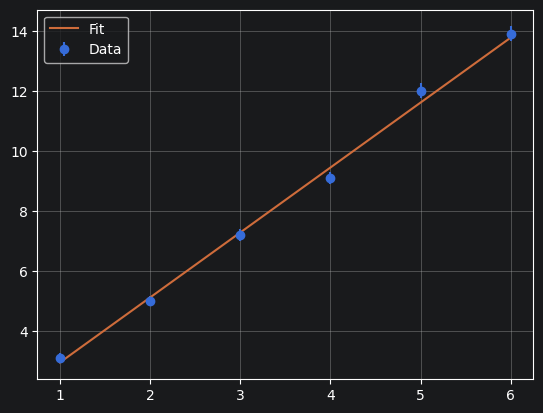

In [372]:
import matplotlib.pyplot as plt

plt.errorbar(x, y, yerr=sy, fmt="o", label="Data")
plt.plot(x, y_fit, label="Fit")
plt.legend()
plt.grid(True)
plt.show()

# We got a reduced chi2 of 1.85 which means sy might be a bit too little.

## Step 7 — Write a function
Objective:
Write a Python function that calculates the chi-squared $\chi^2$ and reduced chi-squared $\chi^2_\nu$ values for a given model fit.

```
def chi2_reduced(y, y_model, errors, n_params):
    ...

```

that returns both $\chi^2$ and $\chi_\nu^2$.

* Task: Test it on datasets using three different models:
  * $y = a x$
  * $y = ax + b$
  * $y = ax^2 + bx + c$
* Plot!

This means fitting each model to the data points using **curve_fit**, and then calculating the chi-squared $\chi^2$ and reduced chi-squared $\chi^2_\nu$ using that function.

Adding more parameters can reduce chi-square, but it also reduces the number of degrees of freedom. A smaller reduced chi-square does not automatically mean a better physical model.


Model 1 (Linear, no int) -> Chi²: 84.94 | Reduced Chi²: 16.99
Model 2 (Linear + int)   -> Chi²: 26.43 | Reduced Chi²: 6.61
Model 3 (Quadratic)      -> Chi²: 0.06 | Reduced Chi²: 0.02


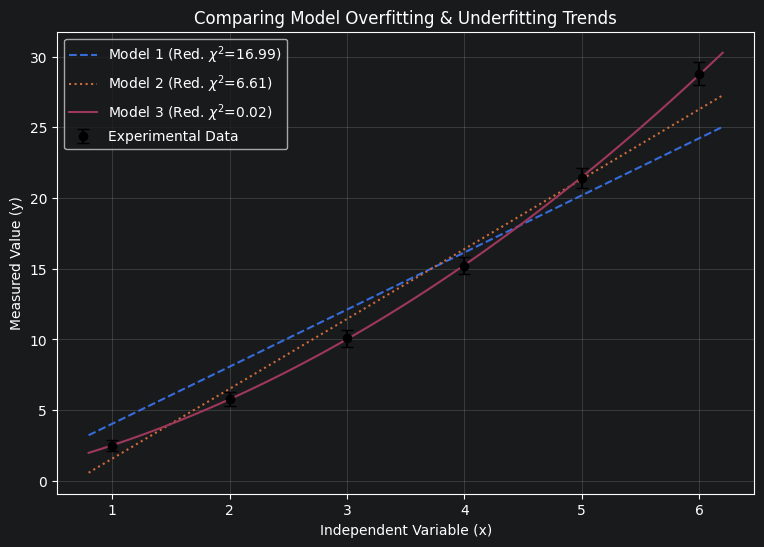

In [375]:
def chi2_squared(y, y_model, errors, n_params):
    chi2 = np.sum(((y - y_model) / errors) ** 2)
    reduced_chi2 = chi2 / (y.size - n_params)
    return chi2, reduced_chi2


def model_1(x, a):
    return a * x


def model_2(x, a, b):
    return a * x + b


def model_3(x, a, b, c):
    return a * (x**2) + b * x + c


np.random.seed(42)  # For reproducible results
x_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
# Base physics path with a minor quadratic inflection + noise
y_data = np.array([2.5, 5.8, 10.1, 15.2, 21.4, 28.8])
errors = np.array([0.4, 0.5, 0.6, 0.6, 0.7, 0.8])

# 3. Fit Model 1 (y = ax)
p1, _ = curve_fit(model_1, x_data, y_data, sigma=errors, absolute_sigma=True)
y_fit1 = model_1(x_data, *p1)
chi2_1, red_chi2_1 = chi2_squared(y_data, y_fit1, errors, n_params=1)

# 4. Fit Model 2 (y = ax + b)
p2, _ = curve_fit(model_2, x_data, y_data, sigma=errors, absolute_sigma=True)
y_fit2 = model_2(x_data, *p2)
chi2_2, red_chi2_2 = chi2_squared(y_data, y_fit2, errors, n_params=2)

# 5. Fit Model 3 (y = ax^2 + bx + c)
p3, _ = curve_fit(model_3, x_data, y_data, sigma=errors, absolute_sigma=True)
y_fit3 = model_3(x_data, *p3)
chi2_3, red_chi2_3 = chi2_squared(y_data, y_fit3, errors, n_params=3)

# 6. Printing Metrics Table
print(
    f"Model 1 (Linear, no int) -> Chi²: {chi2_1:.2f} | Reduced Chi²: {red_chi2_1:.2f}"
)
print(
    f"Model 2 (Linear + int)   -> Chi²: {chi2_2:.2f} | Reduced Chi²: {red_chi2_2:.2f}"
)
print(
    f"Model 3 (Quadratic)      -> Chi²: {chi2_3:.2f} | Reduced Chi²: {red_chi2_3:.2f}"
)

# 7. Visualization Plotting
plt.figure(figsize=(9, 6))
# Fine-grained X array to draw smooth curve trajectories
x_fine = np.linspace(0.8, 6.2, 100)

plt.errorbar(
    x_data,
    y_data,
    yerr=errors,
    fmt="o",
    color="black",
    label="Experimental Data",
    capsize=4,
)
plt.plot(
    x_fine,
    model_1(x_fine, *p1),
    "--",
    label=rf"Model 1 (Red. $\chi^2$={red_chi2_1:.2f})",
)
plt.plot(
    x_fine,
    model_2(x_fine, *p2),
    ":",
    label=rf"Model 2 (Red. $\chi^2$={red_chi2_2:.2f})",
)
plt.plot(
    x_fine,
    model_3(x_fine, *p3),
    "-",
    label=rf"Model 3 (Red. $\chi^2$={red_chi2_3:.2f})",
)

plt.title("Comparing Model Overfitting & Underfitting Trends")
plt.xlabel("Independent Variable (x)")
plt.ylabel("Measured Value (y)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 8 — Conclude

* If $\chi_\nu^2 \approx 1$ → good uncertainties and reasonable model.
* If $\chi_\nu^2 \gg 1$ → model missing physics or underestimated errors.
* If $\chi_\nu^2 \ll 1$ → overestimated uncertainties or overfitting.

Write one sentence explaining which case applies to your data.

In the first two models you can see in the graph the model doesn't represent the measurements.
For the third, the data was generated to be quadratic and there's very few DoFs, so chi is very small -- overfitting.

Model 1 (Linear, no int) -> Reduced Chi²: 68.242
Model 2 (Linear + int)   -> Reduced Chi²: 36.604
Model 3 (Quadratic)      -> Reduced Chi²: 0.889


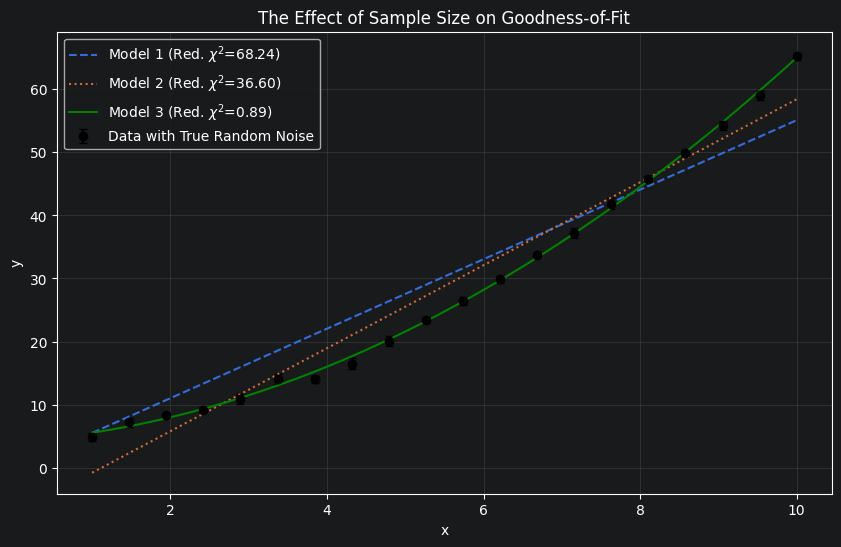

In [377]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


# Define the models
def model_1(x, a):
    return a * x


def model_2(x, a, b):
    return a * x + b


def model_3(x, a, b, c):
    return a * (x**2) + b * x + c


def chi2_reduced(y, y_model, errors, n_params):
    chi2 = np.sum(((y - y_model) / errors) ** 2)
    dof = y.size - n_params
    return chi2, chi2 / dof


# 1. Generate 20 points along a quadratic curve with randomized normal noise
np.random.seed(101)  # Fixed seed so you get the exact same clean results
x_data = np.linspace(1, 10, 20)

# True physical path: y = 0.5*x^2 + 1.2*x + 3.0
y_true = 0.5 * (x_data**2) + 1.2 * x_data + 3.0

# Generate realistic measurement errors (standard deviations)
errors = (
    np.uniform(0.4, 0.9, size=x_data.size)
    if hasattr(np, "uniform")
    else np.random.uniform(0.4, 0.9, size=x_data.size)
)

# Add random Gaussian noise scaled exactly to those errors
noise = np.random.normal(0, errors)
y_data = y_true + noise

# 2. Fit and calculate for Model 1
p1, _ = curve_fit(model_1, x_data, y_data, sigma=errors, absolute_sigma=True)
y_fit1 = model_1(x_data, *p1)
_, red_chi2_1 = chi2_reduced(y_data, y_fit1, errors, n_params=1)

# 3. Fit and calculate for Model 2
p2, _ = curve_fit(model_2, x_data, y_data, sigma=errors, absolute_sigma=True)
y_fit2 = model_2(x_data, *p2)
_, red_chi2_2 = chi2_reduced(y_data, y_fit2, errors, n_params=2)

# 4. Fit and calculate for Model 3
p3, _ = curve_fit(model_3, x_data, y_data, sigma=errors, absolute_sigma=True)
y_fit3 = model_3(x_data, *p3)
_, red_chi2_3 = chi2_reduced(y_data, y_fit3, errors, n_params=3)

# Print results
print(f"Model 1 (Linear, no int) -> Reduced Chi²: {red_chi2_1:.3f}")
print(f"Model 2 (Linear + int)   -> Reduced Chi²: {red_chi2_2:.3f}")
print(f"Model 3 (Quadratic)      -> Reduced Chi²: {red_chi2_3:.3f}")

# Plotting
plt.figure(figsize=(10, 6))
x_fine = np.linspace(1, 10, 100)

plt.errorbar(
    x_data,
    y_data,
    yerr=errors,
    fmt="o",
    color="black",
    label="Data with True Random Noise",
    capsize=3,
)
plt.plot(
    x_fine,
    model_1(x_fine, *p1),
    "--",
    label=rf"Model 1 (Red. $\chi^2$={red_chi2_1:.2f})",
)
plt.plot(
    x_fine,
    model_2(x_fine, *p2),
    ":",
    label=rf"Model 2 (Red. $\chi^2$={red_chi2_2:.2f})",
)
plt.plot(
    x_fine,
    model_3(x_fine, *p3),
    "-",
    color="green",
    label=rf"Model 3 (Red. $\chi^2$={red_chi2_3:.2f})",
)

plt.title("The Effect of Sample Size on Goodness-of-Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()